<center>
<h1 style="color: mediumseagreen">Predictive Credit Risk Modeling for JPMorgan Chase Decision Support </h1>
</center>

<p align="center">
<img src="Chase_Loans.webp" alt="Chase Loans" />
</p>

## <span style="color:blue">Problem Statement</span>

**Lenders process a high volume of consumer loan applications, yet borrower credit risk and loan approval outcomes vary widely due to the combined effects of credit history, income, debt obligations, and repayment behavior. This variability makes it challenging to consistently identify risk while maintaining fair and prudent lending decisions. The objective of this project is to use predictive analytics to identify the key drivers of credit risk and to develop interpretable models that support risk-informed credit decisioning.**

### <span style="color:green">Context</span>

Chase is one of the largest consumer banking institutions in the United States, with significant exposure to retail lending products such as personal loans, auto loans, and credit cards. Accurate assessment of borrower creditworthiness is essential to maintaining portfolio health, ensuring fair and consistent lending practices, and meeting regulatory expectations.

The loan application dataset used in this analysis contains detailed borrower-level financial and credit attributes, including credit scores, income, debt-to-income ratios, payment history, loan characteristics, and approval indicators. While the dataset is comprehensive, credit risk is inherently multidimensional. Borrowers with similar income or credit scores may exhibit materially different risk profiles due to leverage, credit utilization, or prior repayment behavior. A data-driven analytical approach is therefore required to isolate key risk drivers and support transparent, explainable credit decisions consistent with Chase’s risk governance framework.

### <span style="color:green">Success Criteria</span>
- Identify and clearly explain the top **3–5 drivers** influencing borrower credit risk and loan approval outcomes.
- Produce clear, executive-ready visualizations that highlight risk patterns across borrower segments.
- Develop a **statistically robust and interpretable** predictive model to support credit risk assessment.
- Translate analytical findings into **actionable insights** that can inform credit decision support and portfolio oversight.
- Deliver a **fully documented and reproducible** analytical workflow to support transparency and auditability.

### <span style="color:green">Project Scope</span>
**In Scope**
- Exploratory analysis of borrower financial, credit, and behavioral variables.
- Identification of key factors influencing credit risk and loan approval decisions.
- Analysis of leverage and repayment indicators such as debt-to-income ratios, credit utilization, and payment history.
- Comparison of approval and risk patterns across borrower segments and loan characteristics.
- Development of regression or predictive models to estimate borrower risk and support decisioning.

**Out of Scope**
- Automated or real-time credit decision implementation
- Model deployment or production integration
- Use of external credit bureau or macroeconomic datasets
- Longitudinal performance tracking beyond the available dataset period

### <span style="color:green">Project Constraints</span>
- The dataset represents a single snapshot in time, limiting long-term performance evaluation.
- Missing values and skewed distributions may affect statistical inference and model stability.
- Certain behavioral indicators serve as proxies due to the absence of transaction-level data.
- Outliers may influence both descriptive and predictive results.
- Model outputs are intended to support, not replace, existing underwriting and risk review processes.

## <span style="color:blue">Issue Tree – Credit Risk & Loan Decisioning Analysis</span>

### Central Question
**What drives borrower credit risk and loan approval outcomes, and how can analytics support more risk-informed credit decisions?**

#### **1. Credit Risk Drivers – What influences borrower risk?**
- Credit score and length of credit history  
- Debt-to-income ratio and overall leverage  
- Payment history, prior defaults, and bankruptcy history  
- Credit utilization and recent credit inquiries  

#### **2. Approval Drivers – What affects loan approval decisions?**
- Risk score thresholds and credit policy rules  
- Income level and employment stability  
- Loan amount and loan duration  
- Existing monthly debt obligations  

#### **3. Borrower Segmentation – How does risk vary across customer groups?**
- Credit quality tiers (bands)  
- Income and net worth segments  
- Loan purpose and product characteristics  
- Home ownership & marital status segments  

#### **4. Business Insights – What actions are supported by the data?**
- More consistent, risk-aligned decisioning  
- Early identification of higher-risk applicants  
- Portfolio monitoring by segment (purpose, credit tier, DTI)  
- Support for responsible lending & governance


## <span style="color:blue">Loading Data and Setup Jupyter Notebook</span> 

In [10]:
# Download and install Python packages (libraries)
!pip install pandas

In [11]:
# Import core libraries for data analysis, visualization, and statistical modeling
# matplotlib & seaborn: data visualization
# pandas: data manipulation and analysis
# statsmodels: statistical modeling and regression analysis
# Configure inline plotting, visual style, and default figure size for consistency

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
import statsmodels.api as sm

sns.set_style("darkgrid")
mpl.rcParams['figure.figsize'] = (20, 5)

In [12]:
# Load the raw Airbnb dataset from a CSV file into a pandas DataFrame
df_raw = pd.read_csv("Capstone2_Chase_Loancsv.csv") 

# Display the DataFrame to inspect its structure, columns, and initial rows
df_raw.head(5)

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [13]:
# Summary statistics for numerical features
df_raw.describe() 

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [14]:
# Display dataset structure, data types, and missing values
df_raw.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

## <span style="color:blue">Data Cleansing</span> 

In [143]:
df = df_raw.copy()
import re

df.columns = (
    df.columns
      .str.strip()
      .str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True)
)
df.head()

,Application_Date,Age,Annual_Income,Credit_Score,Employment_Status,Education_Level,Experience,Loan_Amount,Loan_Duration,Marital_Status,...,Monthly_Income,Utility_Bills_Payment_History,Job_Tenure,Net_Worth,Base_Interest_Rate,Interest_Rate,Monthly_Loan_Payment,Total_Debt_To_Income_Ratio,Loan_Approved,Risk_Score
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [145]:
# 1) Remove duplicate rows
df = df.drop_duplicates()
# -----------------------------
# 2) Parse dates if present
if "Application_Date" in df.columns:
    df["Application_Date"] = pd.to_datetime(df["Application_Date"], errors="coerce")

# -----------------------------
# 3) Handle missing values

# Key fields commonly used for analysis/modeling
key_cols = [
    "Age", "Annual_Income", "Credit_Score", "Debt_To_Income_Ratio",
    "Loan_Amount", "Interest_Rate", "Loan_Approved", "Risk_Score"
]
existing_key_cols = [c for c in key_cols if c in df.columns]
if existing_key_cols:
    df = df.dropna(subset=existing_key_cols)

# Fill missing numeric "count-like" fields with 0
fill_zero_cols = [
    "Number_Of_Dependents",
    "Number_Of_Open_Credit_Lines",
    "Number_Of_Credit_Inquiries",
    "Previous_Loan_Defaults",
    "Bankruptcy_History"
]
for c in fill_zero_cols:
    if c in df.columns:
        df[c] = df[c].fillna(0)

# Fill missing categorical fields with "Unknown"
fill_unknown_cols = ["Employment_Status", "Education_Level", "Marital_Status", "Home_Ownership_Status", "Loan_Purpose"]
for c in fill_unknown_cols:
    if c in df.columns:
        df[c] = df[c].fillna("Unknown")

# -----------------------------
# 4) Fix data types (numeric conversions)
numeric_cols = [
    "Age", "Annual_Income", "Credit_Score", "Experience", "Loan_Amount", "Loan_Duration",
    "Monthly_Debt_Payments", "Credit_Card_Utilization_Rate", "Number_Of_Open_Credit_Lines",
    "Number_Of_Credit_Inquiries", "Debt_To_Income_Ratio", "Payment_History", "Length_Of_Credit_History",
    "Savings_Account_Balance", "Checking_Account_Balance", "Total_Assets", "Total_Liabilities",
    "Monthly_Income", "Utility_Bills_Payment_History", "Job_Tenure", "Net_Worth",
    "Base_Interest_Rate", "Interest_Rate", "Monthly_Loan_Payment", "Total_Debt_To_Income_Ratio",
    "Loan_Approved", "Risk_Score"
]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop rows that became NaN after conversion in key numeric cols
must_be_numeric = ["Age", "Annual_Income", "Credit_Score", "Loan_Amount", "Interest_Rate"]
must_be_numeric = [c for c in must_be_numeric if c in df.columns]
if must_be_numeric:
    df = df.dropna(subset=must_be_numeric)

# -----------------------------
# 5) Remove invalid / impossible values (sanity checks)
if "Age" in df.columns:
    df = df[df["Age"].between(18, 100)]

if "Credit_Score" in df.columns:
    df = df[df["Credit_Score"].between(300, 850)]

if "Loan_Amount" in df.columns:
    df = df[df["Loan_Amount"] > 0]

if "Annual_Income" in df.columns:
    df = df[df["Annual_Income"] > 0]

# Ratios: keep non-negative
ratio_cols = ["Debt_To_Income_Ratio", "Total_Debt_To_Income_Ratio", "Credit_Card_Utilization_Rate"]
for c in ratio_cols:
    if c in df.columns:
        df = df[df[c].notna() & (df[c] >= 0)]

# Interest Rate: your data seems like decimals (0.12 = 12%). Keep within (0,1).
# If your data is in percent (e.g., 12.5), change < 1 to < 100.
if "Interest_Rate" in df.columns:
    df = df[(df["Interest_Rate"] > 0) & (df["Interest_Rate"] < 1)]

# -----------------------------
# 6) Quick validation summary
print("Rows after cleansing:", len(df))
print("\nMissing values (after cleansing):")
print(df.isnull().sum().sort_values(ascending=False).head(12))

df.head()

Rows after cleansing: 20000

Missing values (after cleansing):
Application_Date                 0
Age                              0
Payment_History                  0
Length_Of_Credit_History         0
Savings_Account_Balance          0
Checking_Account_Balance         0
Total_Assets                     0
Total_Liabilities                0
Monthly_Income                   0
Utility_Bills_Payment_History    0
Job_Tenure                       0
Net_Worth                        0
dtype: int64


,Application_Date,Age,Annual_Income,Credit_Score,Employment_Status,Education_Level,Experience,Loan_Amount,Loan_Duration,Marital_Status,...,Monthly_Income,Utility_Bills_Payment_History,Job_Tenure,Net_Worth,Base_Interest_Rate,Interest_Rate,Monthly_Loan_Payment,Total_Debt_To_Income_Ratio,Loan_Approved,Risk_Score
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


## <span style="color:blue">Data Analysis & Exploratory Insights</span>

### <span style="color:green">Credit Risk Drivers</span> 
#### <span style="color:black">Credit quality (credit score, history)</span> 

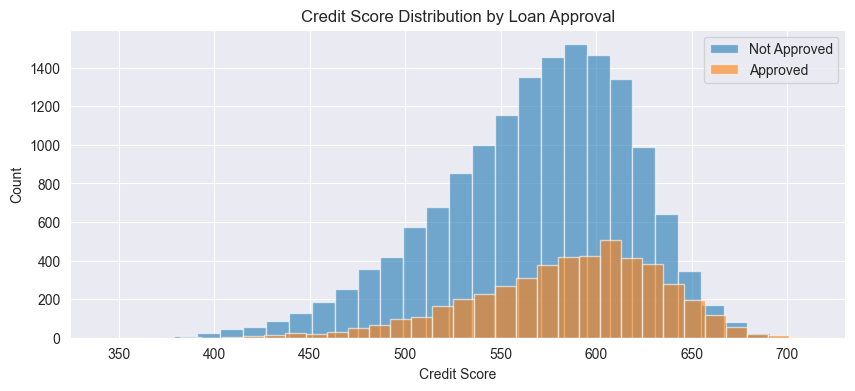

In [343]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create credit score bands
if "Credit_Score" in df.columns:
    df["Credit_Score_Band"] = pd.cut(
        df["Credit_Score"],
        bins=[300, 580, 670, 740, 850],
        labels=["Poor", "Fair", "Good", "Excellent"],
        include_lowest=True
    )

# Plot 1 — Credit Score distribution
if "Loan_Approved" in df.columns:
    plt.figure(figsize=(10,4))
    plt.hist(df.loc[df["Loan_Approved"]==0, "Credit_Score"].dropna(), bins=30, alpha=0.6, label="Not Approved")
    plt.hist(df.loc[df["Loan_Approved"]==1, "Credit_Score"].dropna(), bins=30, alpha=0.6, label="Approved")
    plt.title("Credit Score Distribution by Loan Approval")
    plt.xlabel("Credit Score")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

**The distribution shows that approved loans are concentrated at higher credit scores, while not-approved applications dominate the lower score ranges. There is a clear rightward shift in the approved distribution, confirming credit score as a strong driver of loan approval. However, the noticeable overlap in the mid-range credit scores indicates that credit score alone does not fully determine approval outcomes, suggesting that additional factors such as debt-to-income ratio, income stability, and prior credit history play an important role in lending decisions.**

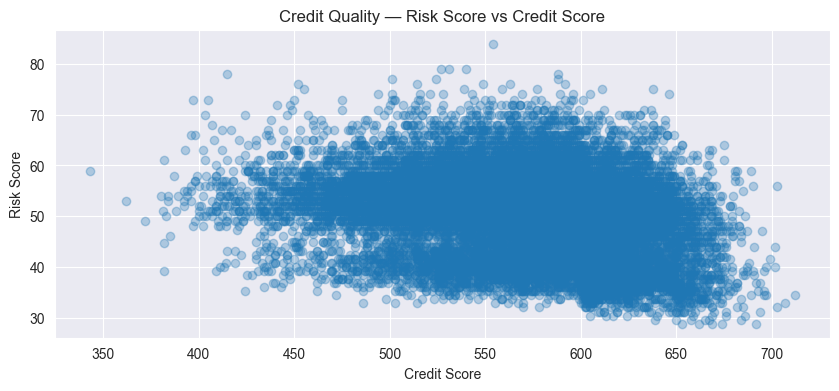

In [270]:
# Plot 2 — Risk Score vs Credit Score
plt.figure(figsize=(10,4))
plt.scatter(df["Credit_Score"], df["Risk_Score"], alpha=0.3)
plt.title("Credit Quality — Risk Score vs Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Risk Score")
plt.show()


**The plot shows a clear inverse relationship between credit score and risk score, with higher credit scores generally associated with lower borrower risk. However, the wide dispersion of points at each credit score level indicates that credit score alone does not fully explain risk, emphasizing the role of additional financial and behavioral factors.**

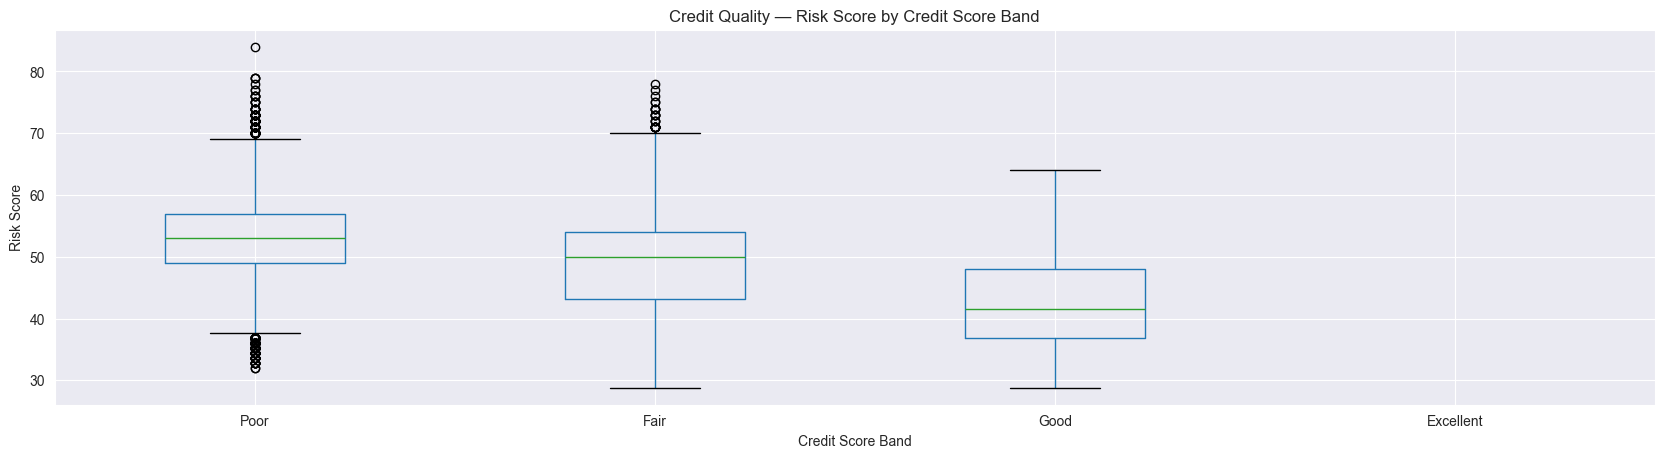

In [435]:
# Plot 3 — Risk score by Credit Score Band
if {"Credit_Score_Band", "Risk_Score"}.issubset(df.columns):
    df.boxplot(column="Risk_Score", by="Credit_Score_Band")
    plt.title("Credit Quality — Risk Score by Credit Score Band")
    plt.suptitle("")
    plt.xlabel("Credit Score Band")
    plt.ylabel("Risk Score")
    plt.show()

**The boxplot shows a clear downward shift in risk score as credit score bands improve, indicating that borrowers in higher credit quality tiers consistently exhibit lower risk. The median risk score decreases from the “Poor” to the “Good” band, and the interquartile range narrows, suggesting greater stability among higher-quality borrowers. While some overlap and outliers remain across bands, the overall pattern confirms credit score banding as an effective way to segment borrower risk.**

#### <span style="color:black">Risk Score Distribution</span> 

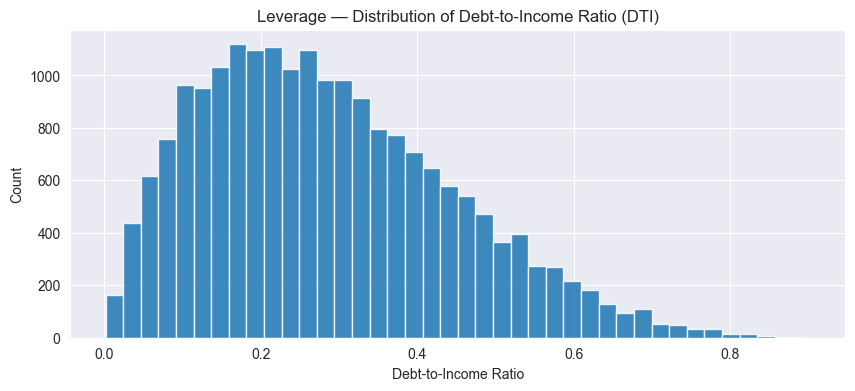

In [277]:
# Plot 1 — DTI distribution
plt.figure(figsize=(10,4))
plt.hist(df["Debt_To_Income_Ratio"].dropna(), bins=40, alpha=0.85)
plt.title("Leverage — Distribution of Debt-to-Income Ratio (DTI)")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Count")
plt.show()

**The distribution shows that most borrowers have debt-to-income ratios concentrated between approximately 0.1 and 0.4, indicating moderate leverage for the majority of applicants. The right-skewed tail suggests a smaller group of borrowers with very high DTI levels, representing higher financial stress and elevated credit risk. This pattern supports the use of DTI as a key underwriting constraint, where higher ratios signal increased risk and reduced loan approval likelihood.**

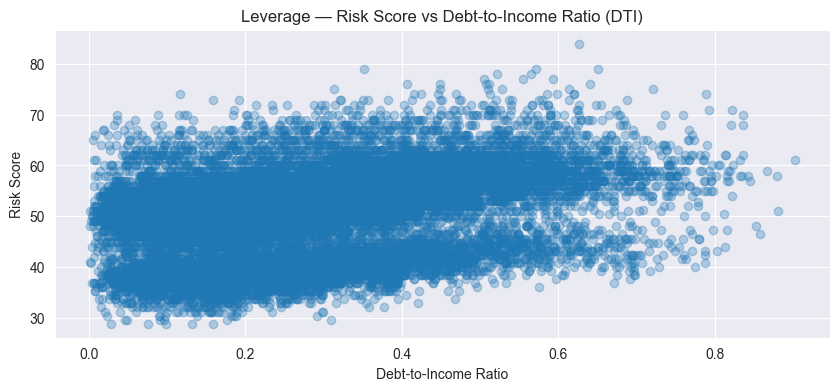

In [279]:
# Plot 2 — Risk score vs DTI
plt.figure(figsize=(10,4))
plt.scatter(df["Debt_To_Income_Ratio"], df["Risk_Score"], alpha=0.3)
plt.title("Leverage — Risk Score vs Debt-to-Income Ratio (DTI)")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Risk Score")
plt.show()


**The scatter plot shows a positive relationship between debt-to-income ratio and risk score, indicating that borrowers with higher leverage generally exhibit higher credit risk. While risk increases as DTI rises, the wide dispersion at each DTI level suggests that leverage alone does not fully determine risk, reinforcing the importance of combining DTI with credit quality and behavioral factors in risk assessment.**

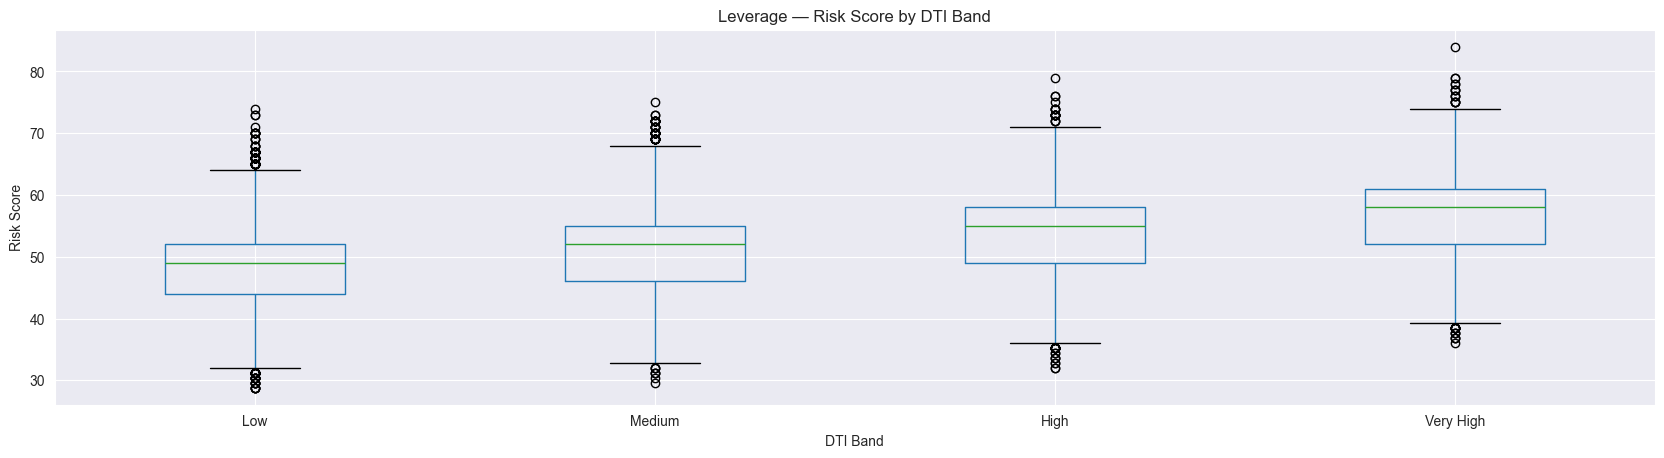

In [283]:
# Plot 3 — Risk score by DTI bands
df["DTI_Band"] = pd.cut(
    df["Debt_To_Income_Ratio"],
    bins=[-0.001, 0.20, 0.35, 0.50, 1.50],
    labels=["Low", "Medium", "High", "Very High"]
)

df.boxplot(column="Risk_Score", by="DTI_Band")
plt.title("Leverage — Risk Score by DTI Band")
plt.suptitle("")
plt.xlabel("DTI Band")
plt.ylabel("Risk Score")
plt.show()

**The boxplot shows a clear increase in median risk score as borrowers move from low to very high debt-to-income (DTI) bands, indicating that higher leverage is consistently associated with greater credit risk. The upward shift and widening spread across DTI bands suggest not only higher average risk but also greater variability among highly leveraged borrowers. This pattern confirms DTI banding as an effective way to segment borrower risk and supports its use as a key underwriting constraint.**

#### <span style="color:black">Repayment behavior & credit events (defaults, bankruptcy, payment history)</span> 

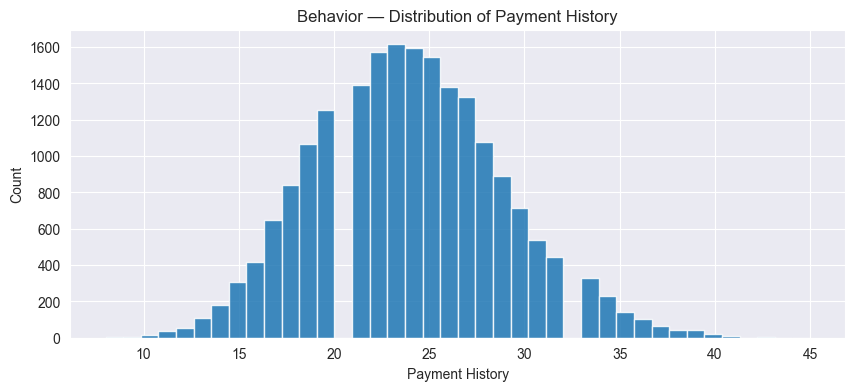

In [289]:
# Plot 1 — Payment history distribution (if exists)
if "Payment_History" in df.columns:
    plt.figure(figsize=(10,4))
    plt.hist(df["Payment_History"].dropna(), bins=40, alpha=0.85)
    plt.title("Behavior — Distribution of Payment History")
    plt.xlabel("Payment History")
    plt.ylabel("Count")
    plt.show()

**The distribution shows that most borrowers cluster around moderate payment history values, indicating generally consistent repayment behavior across the portfolio. The right-skewed tail reflects a smaller group of borrowers with poorer payment histories, which likely corresponds to higher credit risk. This pattern supports payment history as a meaningful behavioral indicator, where deteriorating repayment patterns signal increased likelihood of defaults or adverse credit events.**

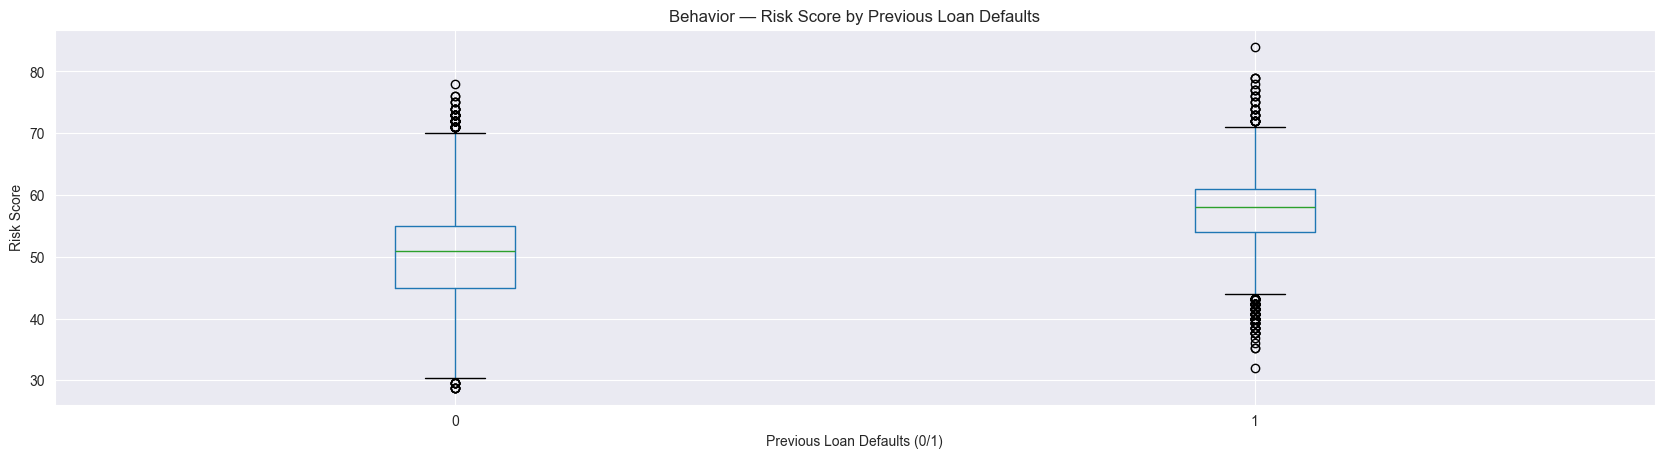

In [293]:
# Plot 2 — Risk score vs previous defaults (box)
if "Previous_Loan_Defaults" in df.columns:
    df.boxplot(column="Risk_Score", by="Previous_Loan_Defaults")
    plt.title("Behavior — Risk Score by Previous Loan Defaults")
    plt.suptitle("")
    plt.xlabel("Previous Loan Defaults (0/1)")
    plt.ylabel("Risk Score")
    plt.show()

**The boxplot shows that borrowers with previous loan defaults have a noticeably higher median risk score compared to those with no default history. The upward shift in both the median and overall distribution indicates that past defaults are strongly associated with elevated credit risk. While some overlap exists, the clear separation confirms previous loan defaults as a powerful behavioral signal for risk assessment and underwriting decisions.**

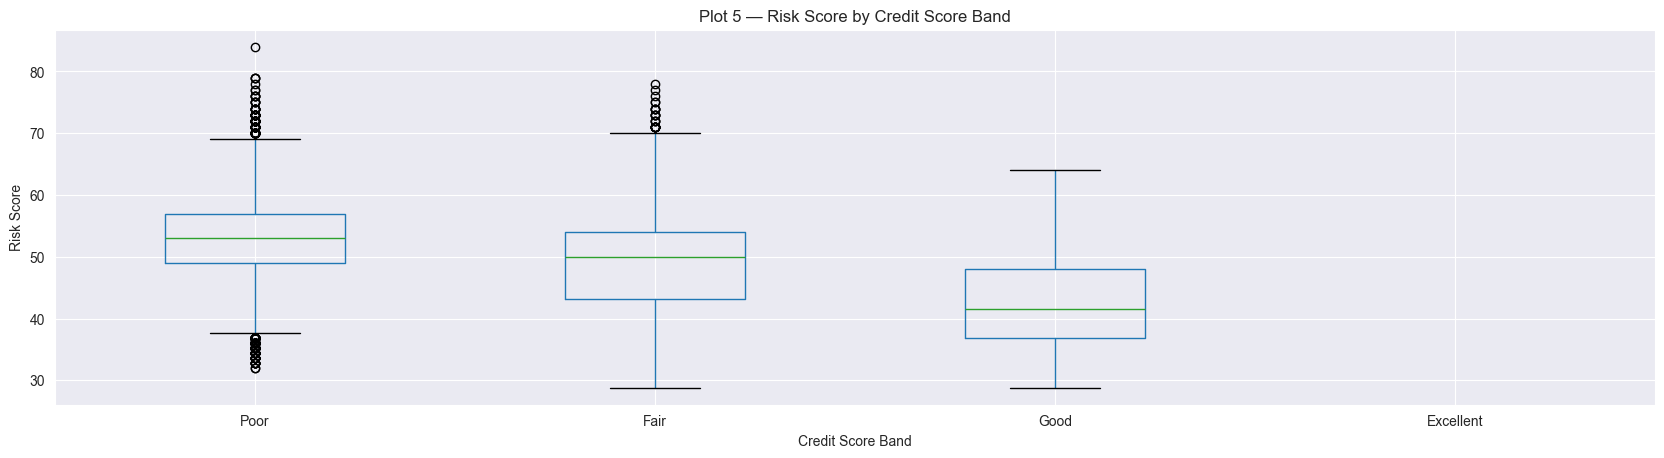

In [345]:
# Plot 3 — Risk score vs credit score band
if {"Risk_Score", "Credit_Score_Band"}.issubset(df.columns):
    df.boxplot(column="Risk_Score", by="Credit_Score_Band")
    plt.title("Plot 5 — Risk Score by Credit Score Band")
    plt.suptitle("")
    plt.xlabel("Credit Score Band")
    plt.ylabel("Risk Score")
    plt.show()

**The boxplot shows a clear and consistent decline in risk scores as credit score bands improve, indicating that borrowers with stronger credit quality exhibit lower and more stable risk levels. Median risk scores decrease from the “Poor” to the “Good” bands, and variability narrows for higher credit tiers, suggesting greater predictability among stronger borrowers. Although some overlap remains across bands, the overall pattern confirms credit score banding as an effective and intuitive way to segment borrower risk for underwriting decisions.**

### <span style="color:green">Approval Drivers</span> 
#### <span style="color:black">Risk thresholds & policy outcomes (risk score and approval)</span> 

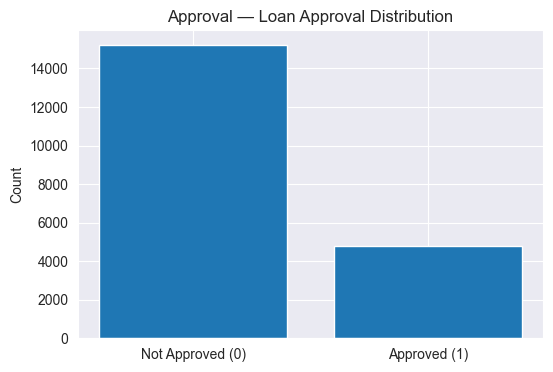

In [305]:
# Plot 1 — Loan approval distribution
counts = df["Loan_Approved"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(["Not Approved (0)", "Approved (1)"], [counts.get(0,0), counts.get(1,0)])
plt.title("Approval — Loan Approval Distribution")
plt.ylabel("Count")
plt.show()

**The bar chart shows that a substantially larger share of loan applications are not approved, indicating a conservative approval policy driven by risk thresholds. This imbalance suggests that approval decisions are tightly constrained by risk-based rules, where only a smaller, lower-risk segment of applicants meets the criteria for approval.**

<Figure size 800x400 with 0 Axes>

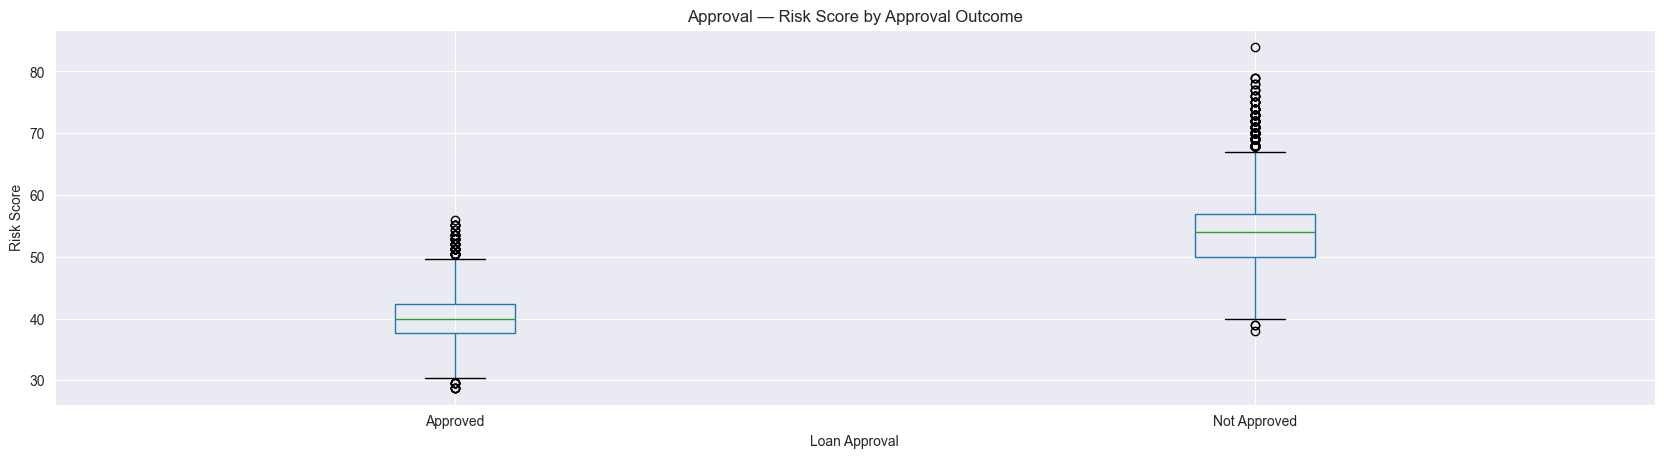

In [307]:
# Plot 2 — Risk score by approval outcome
df["Loan_Approved_Label"] = df["Loan_Approved"].map({0:"Not Approved", 1:"Approved"})
df.boxplot(column="Risk_Score", by="Loan_Approved_Label")
plt.title("Approval — Risk Score by Approval Outcome")
plt.suptitle("")
plt.xlabel("Loan Approval")
plt.ylabel("Risk Score")
plt.show()

**The boxplot shows a clear separation in risk scores between approved and not approved applications, with approved loans having significantly lower median risk scores and a tighter distribution. In contrast, not approved applications exhibit higher and more variable risk scores, indicating that loan approval decisions closely align with underlying risk thresholds and policy rules.**

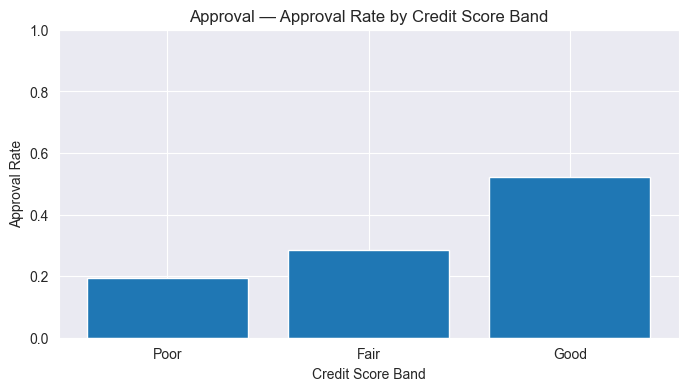

In [309]:
# Plot 3 — Approval rate by credit score band (silence warning with observed=False)
if {"Credit_Score_Band","Loan_Approved"}.issubset(df.columns):
    band_rate = df.groupby("Credit_Score_Band", observed=False)["Loan_Approved"].mean()
    plt.figure(figsize=(8,4))
    plt.bar(band_rate.index.astype(str), band_rate.values)
    plt.title("Approval — Approval Rate by Credit Score Band")
    plt.xlabel("Credit Score Band")
    plt.ylabel("Approval Rate")
    plt.ylim(0,1)
    plt.show()


**The bar chart shows a strong increase in loan approval rates as credit score bands improve. Borrowers in the “Poor” credit band have the lowest approval rates, while approval likelihood rises steadily for “Fair” and peaks for the “Good” band. This clear gradient confirms that credit score bands act as an explicit policy threshold in approval decisions, with higher credit quality translating directly into a higher probability of loan approval.**

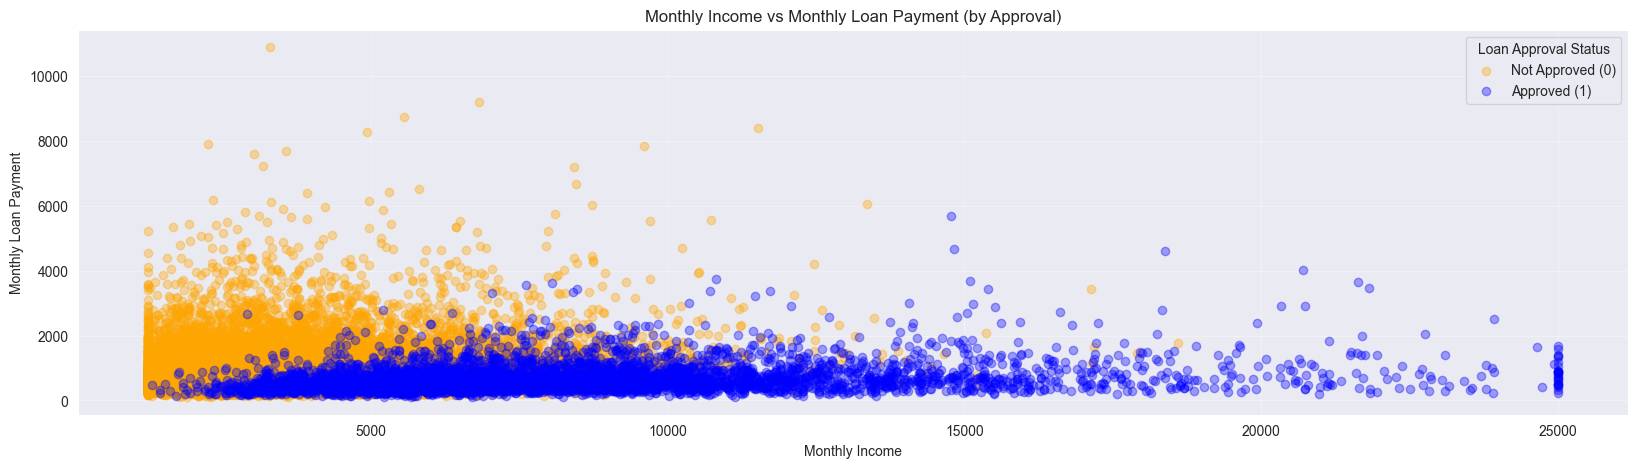

In [356]:
# Plot 4 — Monthly Loan payment vs Monthly income by Loan Approval Status
plt.scatter(
    df.loc[df["Loan_Approved"] == 0, "Monthly_Income"],
    df.loc[df["Loan_Approved"] == 0, "Monthly_Loan_Payment"],
    alpha=0.35, color="orange", label="Not Approved (0)"
)

plt.scatter(
    df.loc[df["Loan_Approved"] == 1, "Monthly_Income"],
    df.loc[df["Loan_Approved"] == 1, "Monthly_Loan_Payment"],
    alpha=0.35, color="blue", label="Approved (1)"
)

plt.xlabel("Monthly Income")
plt.ylabel("Monthly Loan Payment")
plt.title("Monthly Income vs Monthly Loan Payment (by Approval)")
plt.legend(title="Loan Approval Status")
plt.grid(True, alpha=0.3)
plt.show()


**This scatter plot shows a clear affordability pattern in loan approvals. Approved borrowers (blue) tend to have higher monthly incomes relative to their monthly loan payments, clustering along a lower payment-to-income ratio. In contrast, not-approved applicants (orange) are more concentrated at lower income levels with higher or more variable loan payments, indicating heavier repayment burden. The separation suggests that monthly affordability—rather than income or payment alone—is a key approval driver, consistent with lenders favoring applicants whose loan payments consume a smaller share of income.**

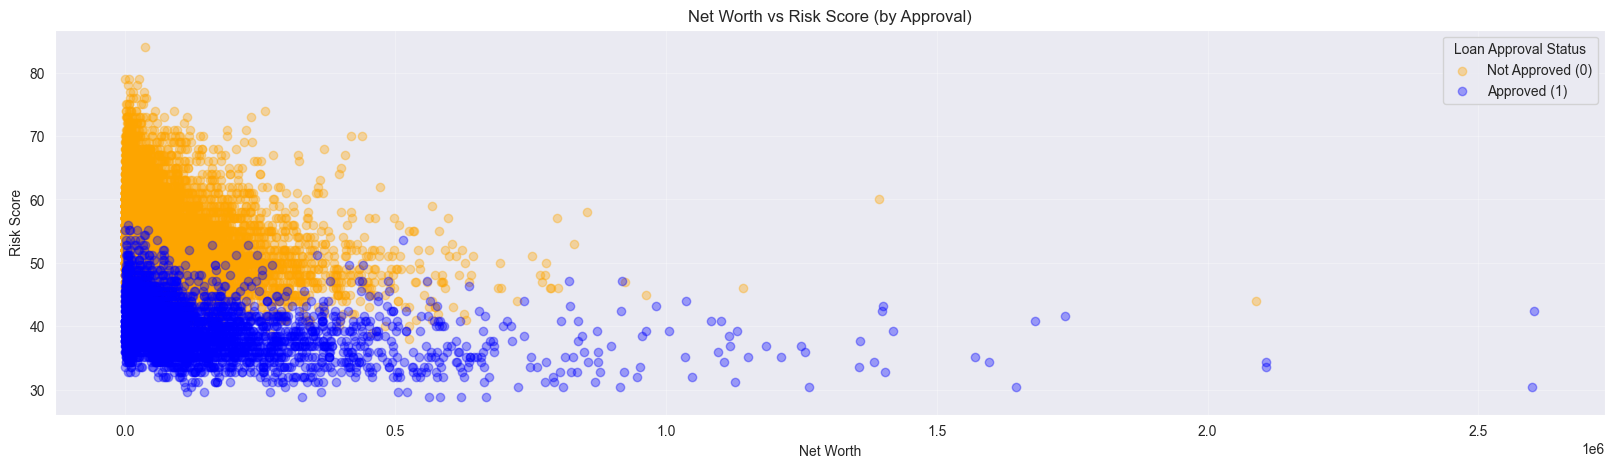

In [358]:
plt.scatter(
    df.loc[df["Loan_Approved"] == 0, "Net_Worth"],
    df.loc[df["Loan_Approved"] == 0, "Risk_Score"],
    alpha=0.35, color="orange", label="Not Approved (0)"
)

plt.scatter(
    df.loc[df["Loan_Approved"] == 1, "Net_Worth"],
    df.loc[df["Loan_Approved"] == 1, "Risk_Score"],
    alpha=0.35, color="blue", label="Approved (1)"
)

plt.xlabel("Net Worth")
plt.ylabel("Risk Score")
plt.title("Net Worth vs Risk Score (by Approval)")
plt.legend(title="Loan Approval Status")
plt.grid(True, alpha=0.3)
plt.show()

**This plot shows that net worth is negatively associated with risk score, and it meaningfully differentiates approval outcomes. Approved borrowers (blue) are concentrated at lower risk scores across a wide range of net worth, including higher net worth levels, indicating stronger financial resilience. In contrast, not-approved applicants (orange) cluster at lower net worth with higher risk scores, reflecting weaker balance sheets and elevated credit risk. Overall, the separation suggests that higher net worth mitigates perceived risk and supports loan approval, even when other factors vary.**

#### <span style="color:black">Income & employment stability</span> 

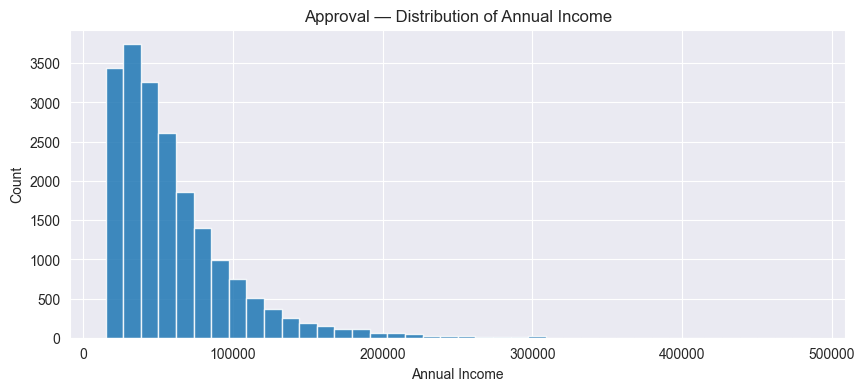

In [315]:
# Plot 1 — Income distribution
plt.figure(figsize=(10,4))
plt.hist(df["Annual_Income"].dropna(), bins=40, alpha=0.85)
plt.title("Approval — Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.show()

**The annual income distribution is right-skewed, with the majority of applicants concentrated in the lower-to-middle income range and a long tail of high-income earners. This indicates that most loan decisions are made for borrowers with modest incomes, while very high incomes are relatively rare. From a risk and approval perspective, income alone may not be sufficient to differentiate borrowers at the lower end, reinforcing the importance of combining income with DTI, risk score, and employment stability in approval decisions.**

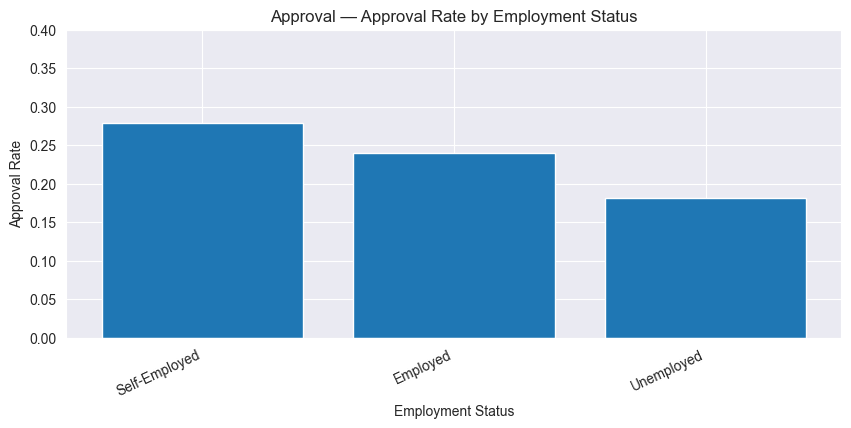

In [319]:
# Plot 2 — Approval rate by Employment Status (if exists)
if "Employment_Status" in df.columns:
    emp_rate = df.groupby("Employment_Status")["Loan_Approved"].mean().sort_values(ascending=False)
    plt.figure(figsize=(10,4))
    plt.bar(emp_rate.index.astype(str), emp_rate.values)
    plt.title("Approval — Approval Rate by Employment Status")
    plt.xlabel("Employment Status")
    plt.ylabel("Approval Rate")
    plt.ylim(0,0.4)
    plt.xticks(rotation=25, ha="right")
    plt.show()

**Approval rates vary meaningfully by employment status, indicating that employment stability is an important approval driver. Self-employed applicants show the highest approval rate, followed by employed borrowers, while unemployed applicants have the lowest likelihood of approval. This pattern suggests that lenders view consistent or verifiable income streams as lower risk, even when income levels may be comparable, reinforcing the role of employment stability alongside income and credit metrics in loan decisioning.**

#### <span style="color:black">Loan amount & duration (loan structure)</span> 

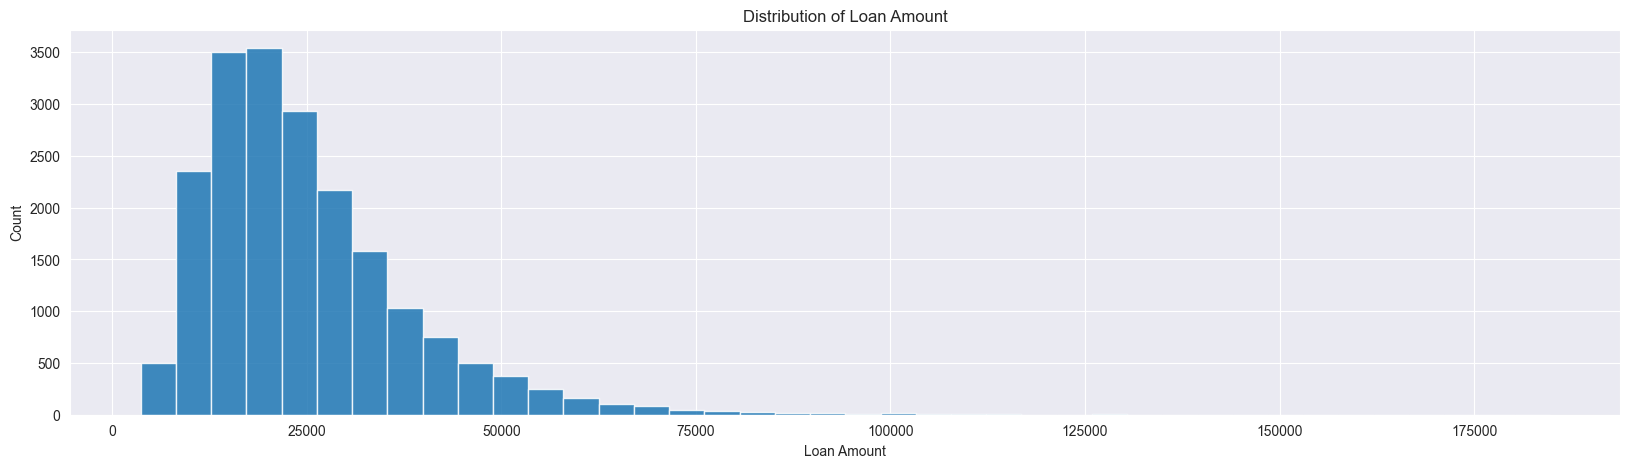

In [325]:
# Plot 1 — Loan amount distribution
plt.hist(df["Loan_Amount"].dropna(), bins=40, alpha=0.85)
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.show()

**The loan amount distribution is right-skewed, with most loans concentrated in the lower-to-mid range, while a small number of borrowers take out substantially larger loans. This indicates that the portfolio is primarily composed of moderate-sized loans, with higher loan amounts representing increased exposure and potential risk. As loan size grows, approval decisions are likely more sensitive to credit quality, income, and DTI, making loan amount an important structural factor in risk-based decisioning.**

### <span style="color:green">Borrower Segmentation</span> 
#### <span style="color:black">Credit quality (credit score, history)</span> 

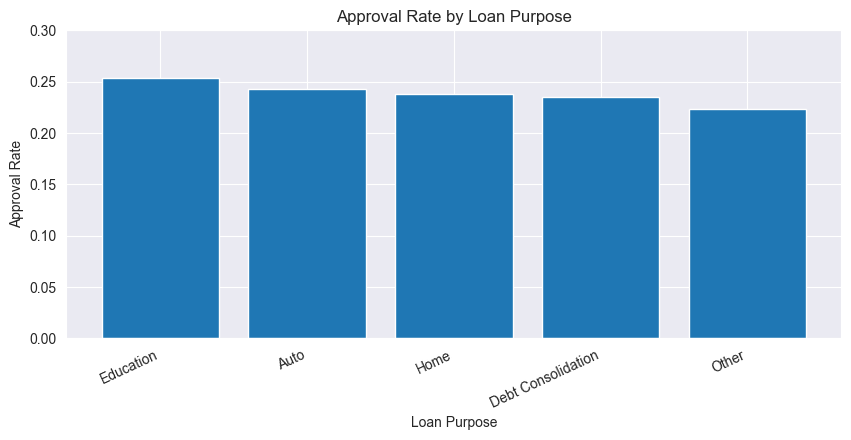

In [339]:
# Plot 1 — Approval rate by Loan Purpose (if exists)
if "Loan_Purpose" in df.columns:
    purpose_rate = df.groupby("Loan_Purpose")["Loan_Approved"].mean().sort_values(ascending=False)
    plt.figure(figsize=(10,4))
    plt.bar(purpose_rate.index.astype(str), purpose_rate.values)
    plt.title("Approval Rate by Loan Purpose")
    plt.xlabel("Loan Purpose")
    plt.ylabel("Approval Rate")
    plt.ylim(0,.3)
    plt.xticks(rotation=25, ha="right")
    plt.show()

**Approval rates differ modestly by loan purpose, suggesting that purpose influences approval decisions but is secondary to core credit factors. Education and auto loans exhibit the highest approval rates, likely reflecting clearer use of funds and more predictable repayment profiles, while “Other” purposes show the lowest approval likelihood, indicating higher uncertainty or risk. Overall, loan purpose acts as a risk modifier rather than a primary driver, refining decisions made based on credit score, DTI, income, and risk score.**

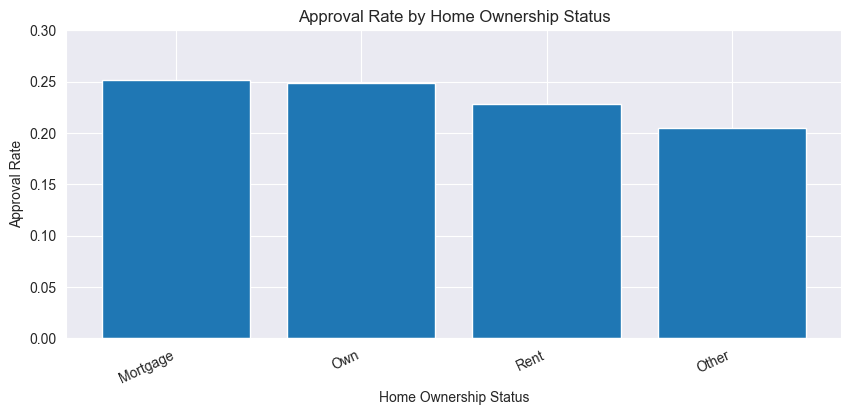

In [341]:
# Plot 2 — Approval rate by Home Ownership (if exists)
if "Home_Ownership_Status" in df.columns:
    home_rate = df.groupby("Home_Ownership_Status")["Loan_Approved"].mean().sort_values(ascending=False)
    plt.figure(figsize=(10,4))
    plt.bar(home_rate.index.astype(str), home_rate.values)
    plt.title("Approval Rate by Home Ownership Status")
    plt.xlabel("Home Ownership Status")
    plt.ylabel("Approval Rate")
    plt.ylim(0,0.3)
    plt.xticks(rotation=25, ha="right")
    plt.show()


**Approval rates increase with stronger housing stability. Applicants with a mortgage or owned homes have the highest approval rates, reflecting greater financial stability and asset backing, while renters and “other” housing statuses show lower approval likelihood. This suggests that home ownership serves as a stabilizing signal in lending decisions, complementing income, credit score, and DTI in assessing borrower risk.**

### <span style="color:green"> Interest Rate Drivers</span> 

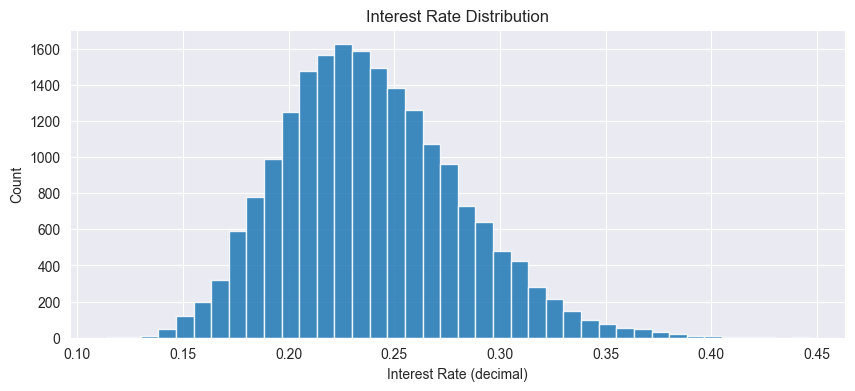

In [349]:
# Plot 1 — Interest rate distribution
plt.figure(figsize=(10,4))
plt.hist(df["Interest_Rate"].dropna(), bins=40, alpha=0.85)
plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate (decimal)")
plt.ylabel("Count")
plt.show()

**The interest rate distribution is unimodal and moderately right-skewed, with most loans priced in a mid-range band, while a smaller share of borrowers face substantially higher rates. This pattern suggests standardized base pricing with risk-based markups applied to higher-risk profiles. The right tail likely reflects borrowers with weaker credit quality, higher DTI, or less stable income, indicating that interest rates are used as a key risk-adjustment lever rather than varying uniformly across all applicants.**

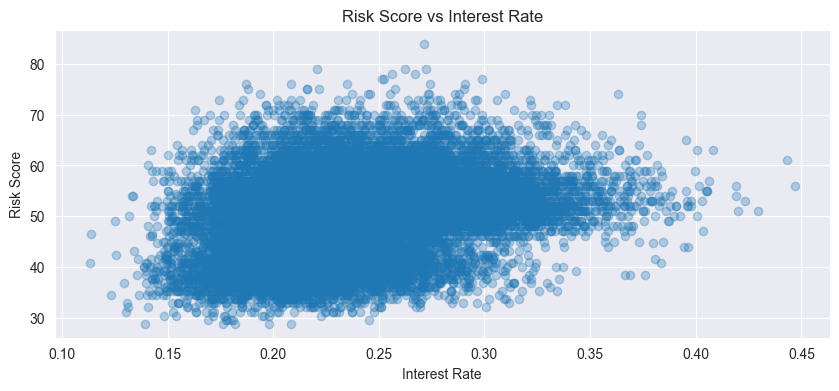

In [352]:
# Plot 2 — Risk Score vs Interest rate
plt.figure(figsize=(10,4))
plt.scatter(df["Interest_Rate"], df["Risk_Score"], alpha=0.3)
plt.title("Risk Score vs Interest Rate")
plt.xlabel("Interest Rate")
plt.ylabel("Risk Score")
plt.show()

**There is a clear positive relationship between risk score and interest rate: borrowers with higher risk scores are generally charged higher interest rates. While there is dispersion at each rate level, the upward trend indicates risk-based pricing, where lenders compensate for increased default risk by applying higher rates. This confirms that interest rate acts as a pricing lever, translating underlying borrower risk (captured by the risk score) directly into loan terms.**

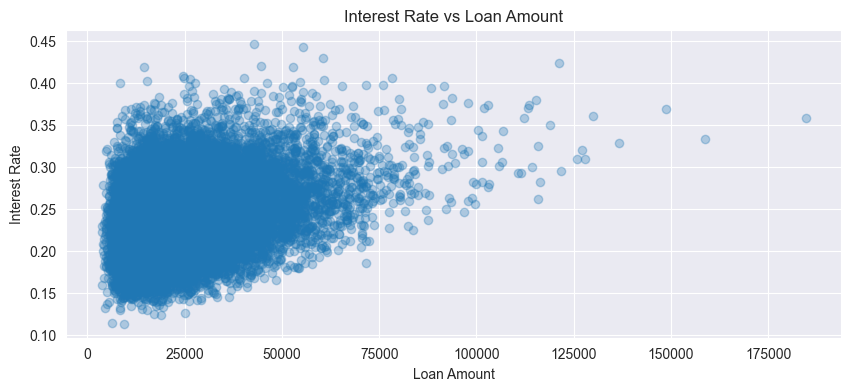

In [370]:
# Plot 3 — Loan Amount vs Interest rate
plt.figure(figsize=(10,4))
plt.scatter(df["Loan_Amount"], df["Interest_Rate"], alpha=0.3)
plt.title("Interest Rate vs Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Interest Rate")
plt.show()

**The relationship between loan amount and interest rate is weakly positive. Larger loans tend to be associated with slightly higher interest rates, but the wide dispersion shows that loan size alone does not drive pricing. Instead, interest rates appear to be primarily determined by borrower risk (e.g., risk score, income stability), with loan amount acting as a secondary or conditional factor—likely constrained by underwriting limits rather than used directly as a pricing lever.**

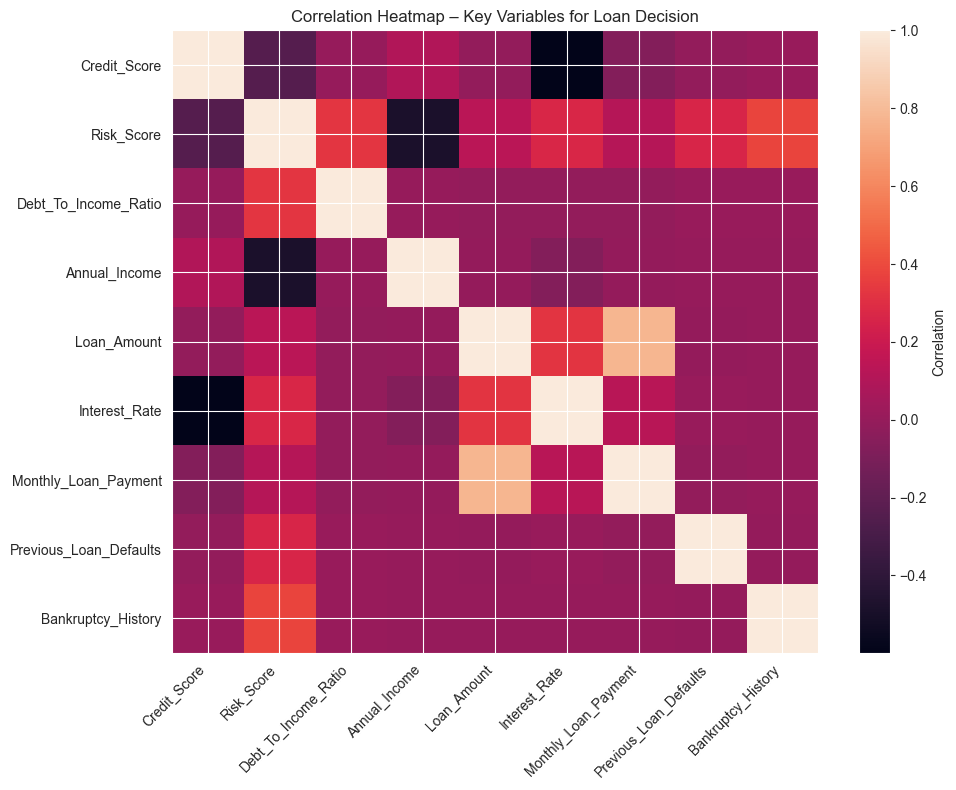

In [376]:
import matplotlib.pyplot as plt

# Select only the most critical variables for loan decisions
critical_vars = [
    "Credit_Score",
    "Risk_Score",
    "Debt_To_Income_Ratio",
    "Annual_Income",
    "Loan_Amount",
    "Interest_Rate",
    "Monthly_Loan_Payment",
    "Previous_Loan_Defaults",
    "Bankruptcy_History"
]

# Keep variables that exist in the dataset
critical_vars = [c for c in critical_vars if c in df.columns]

# Compute correlation matrix
corr = df[critical_vars].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")

plt.title("Correlation Heatmap – Key Variables for Loan Decision")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

plt.tight_layout()
plt.show()


**The correlation heatmap indicates that credit score and risk score are the primary drivers of loan decisions and pricing. Credit score shows a strong negative correlation with both risk score and interest rate, confirming that borrowers with stronger credit profiles are assessed as lower risk and receive lower rates. Risk score is positively correlated with interest rate, previous loan defaults, and bankruptcy history, reinforcing its role as a central underwriting variable. Income-related variables exhibit weaker correlations, suggesting that while affordability matters, it is secondary to credit risk. Loan amount and monthly loan payment are strongly correlated, reflecting internal consistency in loan structuring. Overall, the relationships align with standard lending logic and indicate low multicollinearity, making the dataset suitable for multivariate modeling.**

## <span style="color:blue"> Regression Modeling </span> 
### <span style="color:green">Predictive Modeling</span> 


=== Logistic Regression Summary (with p-values) ===
                           Logit Regression Results                           
Dep. Variable:          Loan_Approved   No. Observations:                14000
Model:                          Logit   Df Residuals:                    13994
Method:                           MLE   Df Model:                            5
Date:                Sun, 11 Jan 2026   Pseudo R-squ.:                  0.3815
Time:                        13:46:17   Log-Likelihood:                -4761.9
converged:                       True   LL-Null:                       -7698.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -1.6301      0.029    -55.540      0.000      -1.688      -1.573
Credit_Score               0.3372      0.02

,Feature,Coefficient,Std_Error,P_Value,Odds_Ratio
0,const,-1.630113,0.029350,0.000000e+00,0.195907
3,Annual_Income,2.045382,0.038971,0.000000e+00,7.732109
1,Credit_Score,0.337177,0.027627,2.934152e-34,1.400988
5,Bankruptcy_History,-0.415584,0.037121,4.299880e-29,0.659955
4,Previous_Loan_Defaults,-0.329670,0.031573,1.601183e-25,0.719161
2,Debt_To_Income_Ratio,0.000246,0.026190,9.925166e-01,1.000246



=== Test Performance ===
Accuracy: 0.849
ROC AUC: 0.886
Confusion Matrix:
 [[4322  244]
 [ 660  774]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4566
           1       0.76      0.54      0.63      1434

    accuracy                           0.85      6000
   macro avg       0.81      0.74      0.77      6000
weighted avg       0.84      0.85      0.84      6000



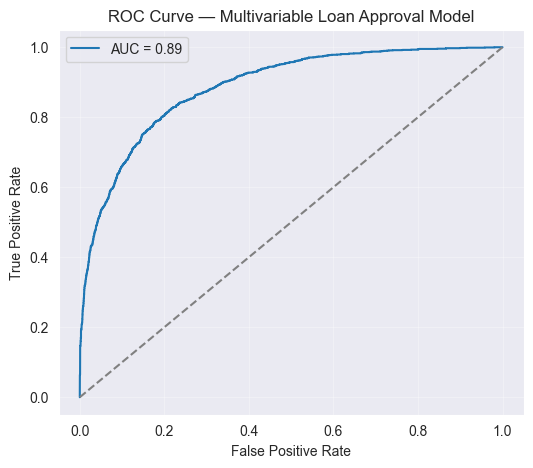

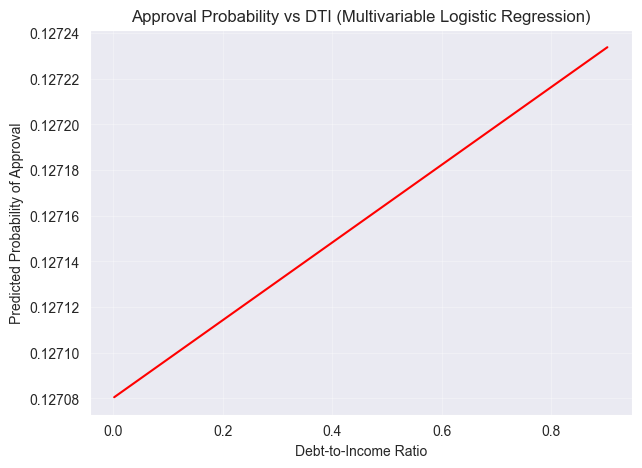

In [482]:
# ============================================================
# MULTIVARIABLE LOGISTIC REGRESSION (FINAL PROJECT VERSION)
# Target: Loan_Approved (0/1)
# Includes: Standardization, p-values, ROC AUC, Precision/Recall,
#           and scaled probability curve
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, accuracy_score,
    classification_report
)

# -----------------------------
# 1) Select variables
features = [
    "Credit_Score",
    "Debt_To_Income_Ratio",
    "Annual_Income",
    "Previous_Loan_Defaults",
    "Bankruptcy_History"
]
target = "Loan_Approved"

df_model = df[features + [target]].copy()

# Ensure numeric & drop missing
for c in features + [target]:
    df_model[c] = pd.to_numeric(df_model[c], errors="coerce")
df_model = df_model.dropna().copy()

X = df_model[features]
y = df_model[target].astype(int)

# -----------------------------
# 2) Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# 3) Standardize features (important for logistic regression)
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=features,
    index=X_test.index
)

# Add intercept
X_train_sm = sm.add_constant(X_train_scaled, has_constant="add")
X_test_sm  = sm.add_constant(X_test_scaled, has_constant="add")

# -----------------------------
# 4) Fit logistic regression (statsmodels → p-values)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit(disp=False)

print("=== Logistic Regression Summary (with p-values) ===")
print(result.summary())

# Coefficients + odds ratios
coef_table = pd.DataFrame({
    "Feature": result.params.index,
    "Coefficient": result.params.values,
    "Std_Error": result.bse.values,
    "P_Value": result.pvalues.values,
    "Odds_Ratio": np.exp(result.params.values)
}).sort_values("P_Value")

print("\n=== Coefficients, P-values, Odds Ratios ===")
display(coef_table)

# -----------------------------
# 5) Test set evaluation
y_prob = result.predict(X_test_sm)
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n=== Test Performance ===")
print(f"Accuracy: {acc:.3f}")
print(f"ROC AUC: {auc:.3f}")
print("Confusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# 6) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Multivariable Loan Approval Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# 7) Probability vs DTI (scaled correctly)
dti_vals = np.linspace(
    df_model["Debt_To_Income_Ratio"].min(),
    df_model["Debt_To_Income_Ratio"].max(),
    200
)

plot_raw = pd.DataFrame({
    "Credit_Score": df_model["Credit_Score"].median(),
    "Debt_To_Income_Ratio": dti_vals,
    "Annual_Income": df_model["Annual_Income"].median(),
    "Previous_Loan_Defaults": 0,
    "Bankruptcy_History": 0
})

plot_scaled = pd.DataFrame(
    scaler.transform(plot_raw),
    columns=features
)

plot_scaled_sm = sm.add_constant(plot_scaled, has_constant="add")
prob_curve = result.predict(plot_scaled_sm)

plt.figure(figsize=(7, 5))
plt.plot(dti_vals, prob_curve, color="red")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Predicted Probability of Approval")
plt.title("Approval Probability vs DTI (Multivariable Logistic Regression)")
plt.grid(alpha=0.3)
plt.show()


**The multivariable logistic regression performs well, achieving 84.9% accuracy and a ROC AUC of 0.89, showing strong ability to distinguish approved from rejected loans. Credit score, annual income, previous defaults, and bankruptcy history are all statistically significant drivers of approval. Higher credit scores and income increase approval likelihood, while defaults and bankruptcy sharply reduce it. Debt-to-income ratio is not significant once other variables are included, which explains the nearly flat approval-probability vs. DTI curve. Overall, the results confirm that loan approval decisions rely on multiple factors rather than any single metric.**

=== Logistic Regression Summary (with p-values) ===
                           Logit Regression Results                           
Dep. Variable:          Loan_Approved   No. Observations:                14000
Model:                          Logit   Df Residuals:                    13995
Method:                           MLE   Df Model:                            4
Date:                Sun, 11 Jan 2026   Pseudo R-squ.:                  0.3815
Time:                        13:46:35   Log-Likelihood:                -4761.9
converged:                       True   LL-Null:                       -7698.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -1.6301      0.029    -55.540      0.000      -1.688      -1.573
Credit_Score               0.3372      0.02

,Feature,Coefficient,Std_Error,P_Value,Odds_Ratio
0,const,-1.630113,0.029350,0.000000e+00,0.195908
2,Annual_Income,2.045383,0.038971,0.000000e+00,7.732121
1,Credit_Score,0.337182,0.027623,2.863654e-34,1.400994
4,Bankruptcy_History,-0.415581,0.037120,4.286101e-29,0.659957
3,Previous_Loan_Defaults,-0.329669,0.031573,1.601408e-25,0.719162



=== Test Performance ===
Accuracy: 0.849
ROC AUC: 0.886
Confusion Matrix:
 [[4322  244]
 [ 660  774]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4566
           1       0.76      0.54      0.63      1434

    accuracy                           0.85      6000
   macro avg       0.81      0.74      0.77      6000
weighted avg       0.84      0.85      0.84      6000



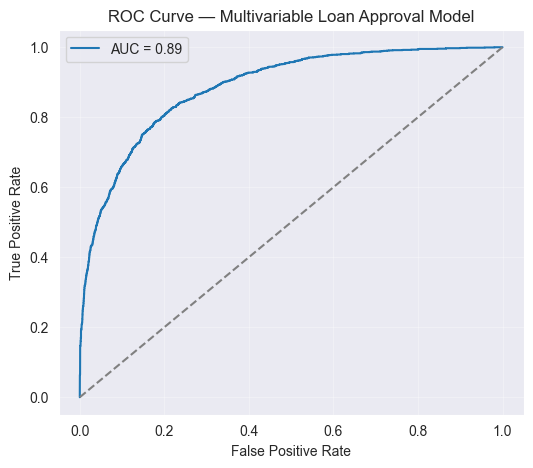

In [484]:
# ============================================================
# MULTIVARIABLE LOGISTIC REGRESSION (FINAL – DTI REMOVED)
# Target: Loan_Approved (0/1)
# Predictors: Credit quality + income + credit history
# Includes: Standardization, p-values, ROC AUC, Precision/Recall
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, accuracy_score,
    classification_report
)

# -----------------------------
# 1) Select variables (DTI removed)
features = [
    "Credit_Score",
    "Annual_Income",
    "Previous_Loan_Defaults",
    "Bankruptcy_History"
]
target = "Loan_Approved"

df_model = df[features + [target]].copy()

# Ensure numeric & drop missing
for c in features + [target]:
    df_model[c] = pd.to_numeric(df_model[c], errors="coerce")
df_model = df_model.dropna().copy()

X = df_model[features]
y = df_model[target].astype(int)

# -----------------------------
# 2) Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# -----------------------------
# 3) Standardize features
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=features,
    index=X_test.index
)

# Add intercept
X_train_sm = sm.add_constant(X_train_scaled, has_constant="add")
X_test_sm  = sm.add_constant(X_test_scaled, has_constant="add")

# -----------------------------
# 4) Fit logistic regression (statsmodels → p-values)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit(disp=False)

print("=== Logistic Regression Summary (with p-values) ===")
print(result.summary())

# Coefficients + odds ratios
coef_table = pd.DataFrame({
    "Feature": result.params.index,
    "Coefficient": result.params.values,
    "Std_Error": result.bse.values,
    "P_Value": result.pvalues.values,
    "Odds_Ratio": np.exp(result.params.values)
}).sort_values("P_Value")

print("\n=== Coefficients, P-values, Odds Ratios ===")
display(coef_table)

# -----------------------------
# 5) Test set evaluation
y_prob = result.predict(X_test_sm)
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n=== Test Performance ===")
print(f"Accuracy: {acc:.3f}")
print(f"ROC AUC: {auc:.3f}")
print("Confusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# 6) ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Multivariable Loan Approval Model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**After removing debt-to-income ratio, the multivariable logistic regression remains strong and interpretable, achieving about 85% accuracy and a ROC AUC of 0.89, indicating excellent discrimination between approved and rejected loans. All remaining predictors-credit score, annual income, previous loan defaults, and bankruptcy history-are statistically significant. Higher credit scores and higher income substantially increase the odds of approval, while prior defaults and bankruptcy history significantly reduce approval likelihood. The ROC curve shows strong separation from the random baseline, confirming robust predictive performance. Overall, this refined model demonstrates that loan approval decisions are driven by a combination of credit quality, income strength, and adverse credit history, rather than affordability ratios once these factors are accounted for.**